In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis_cross-sectional.csv
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis_cross-sectional_facts.pdf
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0398_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0037_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0195_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0326_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0005_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0328_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oas

# Configuration

In [2]:
# ============================================================
# 1. IMPORTS AND ENVIRONMENT CHECK
# ============================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np

print("Python environment ready.")
print("Kaggle input directory:")
print(os.listdir("/kaggle/input"))

Python environment ready.
Kaggle input directory:
['datasets']


In [3]:
# ============================================================
# 2. INSPECT OASIS DATASET
# ============================================================

INPUT_DIR = Path("/kaggle/input/datasets/ninadaithal/oasis-1-shinohara")

for item in INPUT_DIR.iterdir():
    print(item)

/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis_cross-sectional.csv
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis_cross-sectional_facts.pdf


In [4]:
# Show files/directories inside the OASIS dataset
for root, dirs, files in os.walk(INPUT_DIR):
    print("\nROOT:", root)
    print("Number of files:", len(files))
    print("Sample files:", files[:10])
    
    # Don't go infinitely deep
    if root.count(os.sep) > 6:
        dirs[:] = []


ROOT: /kaggle/input/datasets/ninadaithal/oasis-1-shinohara
Number of files: 2
Sample files: ['oasis_cross-sectional.csv', 'oasis_cross-sectional_facts.pdf']

ROOT: /kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis
Number of files: 0
Sample files: []

ROOT: /kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS
Number of files: 436
Sample files: ['OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0398_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0037_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0195_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0326_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0005_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0328_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0134_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0271_MR1_mpr_n4_anon_sbj_111_normalised.nii', 'OAS1_0433_MR1_mpr_n3_anon_sbj_111_normalised.nii']


In [5]:
# ============================================================
# 3. FIND MRI FILES
# ============================================================

mri_extensions = [
    "*.nii",
    "*.nii.gz",
    "*.img",
    "*.hdr"
]

mri_files = []

for ext in mri_extensions:
    mri_files.extend(INPUT_DIR.rglob(ext))

print("Total MRI-related files found:", len(mri_files))

for f in mri_files[:20]:
    print(f)

Total MRI-related files found: 436
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0398_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0037_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0195_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0326_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0005_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0328_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis/OASIS/OAS1_0134_MR1_mpr_n4_anon_sbj_111_normalised.nii
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/

# Find the clinical CSV

In [6]:
# ============================================================
# 4. FIND CSV FILES
# ============================================================

csv_files = list(INPUT_DIR.rglob("*.csv"))

print("CSV files found:", len(csv_files))

for f in csv_files:
    print(f)

CSV files found: 1
/kaggle/input/datasets/ninadaithal/oasis-1-shinohara/oasis_cross-sectional.csv


In [7]:
clinical_path = csv_files[0]

clinical = pd.read_csv(clinical_path)

print("Shape:", clinical.shape)
print("\nColumns:")
print(clinical.columns.tolist())

display(clinical.head())

Shape: (436, 12)

Columns:
['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay']


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,0.0,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,0.0,1737,0.848,1.010,NaN


In [8]:
# ============================================================
# 5. LOAD OASIS CLINICAL DATA
# ============================================================

from pathlib import Path
import pandas as pd

DATA_DIR = Path("/kaggle/input/datasets/ninadaithal/oasis-1-shinohara")

clinical_path = DATA_DIR / "oasis_cross-sectional.csv"

clinical = pd.read_csv(clinical_path)

print("Clinical data shape:", clinical.shape)
print("\nColumns:")
print(clinical.columns.tolist())

print("\nFirst 5 rows:")
display(clinical.head())

Clinical data shape: (436, 12)

Columns:
['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay']

First 5 rows:


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,0.0,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,0.0,1737,0.848,1.010,NaN


In [9]:
# ============================================================
# 6. CLINICAL DATA SUMMARY
# ============================================================

print("Data types:")
display(clinical.dtypes)

print("\nMissing values:")
display(clinical.isnull().sum())

print("\nUnique values:")
for col in clinical.columns:
    print(f"\n{col}:")
    print(clinical[col].unique()[:20])

Data types:


ID        object
M/F       object
Hand      object
Age        int64
Educ     float64
SES      float64
MMSE     float64
CDR      float64
eTIV       int64
nWBV     float64
ASF      float64
Delay    float64
dtype: object


Missing values:


ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64


Unique values:

ID:
['OAS1_0001_MR1' 'OAS1_0002_MR1' 'OAS1_0003_MR1' 'OAS1_0004_MR1'
 'OAS1_0005_MR1' 'OAS1_0006_MR1' 'OAS1_0007_MR1' 'OAS1_0009_MR1'
 'OAS1_0010_MR1' 'OAS1_0011_MR1' 'OAS1_0012_MR1' 'OAS1_0013_MR1'
 'OAS1_0014_MR1' 'OAS1_0015_MR1' 'OAS1_0016_MR1' 'OAS1_0017_MR1'
 'OAS1_0018_MR1' 'OAS1_0019_MR1' 'OAS1_0020_MR1' 'OAS1_0021_MR1']

M/F:
['F' 'M']

Hand:
['R']

Age:
[74 55 73 28 18 24 21 20 52 30 81 19 76 82 39 89 48 80 69 58]

Educ:
[ 2.  4. nan  5.  3.  1.]

SES:
[ 3.  1. nan  2.  4.  5.]

MMSE:
[29. 27. nan 30. 28. 23. 26. 22. 21. 15. 25. 18. 24. 20. 16. 17. 19. 14.]

CDR:
[0.  0.5 1.  2. ]

eTIV:
[1344 1147 1454 1588 1737 1131 1516 1505 1636 1321 1574 1664 1525 1738
 1477 1689 1536 1326 1794 1447]

nWBV:
[0.743 0.81  0.708 0.803 0.848 0.862 0.83  0.843 0.689 0.827 0.842 0.679
 0.856 0.719 0.739 0.845 0.813 0.715 0.785 0.765]

ASF:
[1.306 1.531 1.207 1.105 1.01  1.551 1.157 1.166 1.073 1.329 1.115 1.055
 1.151 1.188 1.039 1.142 1.323 0.978 1.213 1.236]

Delay:
[nan  1. 

In [10]:
# ============================================================
# 6. CLINICAL DATA SUMMARY
# ============================================================

print("Data types:")
display(clinical.dtypes)

print("\nMissing values:")
display(clinical.isnull().sum())

print("\nUnique values:")
for col in clinical.columns:
    print(f"\n{col}:")
    print(clinical[col].unique()[:30])

Data types:


ID        object
M/F       object
Hand      object
Age        int64
Educ     float64
SES      float64
MMSE     float64
CDR      float64
eTIV       int64
nWBV     float64
ASF      float64
Delay    float64
dtype: object


Missing values:


ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64


Unique values:

ID:
['OAS1_0001_MR1' 'OAS1_0002_MR1' 'OAS1_0003_MR1' 'OAS1_0004_MR1'
 'OAS1_0005_MR1' 'OAS1_0006_MR1' 'OAS1_0007_MR1' 'OAS1_0009_MR1'
 'OAS1_0010_MR1' 'OAS1_0011_MR1' 'OAS1_0012_MR1' 'OAS1_0013_MR1'
 'OAS1_0014_MR1' 'OAS1_0015_MR1' 'OAS1_0016_MR1' 'OAS1_0017_MR1'
 'OAS1_0018_MR1' 'OAS1_0019_MR1' 'OAS1_0020_MR1' 'OAS1_0021_MR1'
 'OAS1_0022_MR1' 'OAS1_0023_MR1' 'OAS1_0025_MR1' 'OAS1_0026_MR1'
 'OAS1_0027_MR1' 'OAS1_0028_MR1' 'OAS1_0029_MR1' 'OAS1_0030_MR1'
 'OAS1_0031_MR1' 'OAS1_0032_MR1']

M/F:
['F' 'M']

Hand:
['R']

Age:
[74 55 73 28 18 24 21 20 52 30 81 19 76 82 39 89 48 80 69 58 43 86 65 88
 51 84 27 23 70 38]

Educ:
[ 2.  4. nan  5.  3.  1.]

SES:
[ 3.  1. nan  2.  4.  5.]

MMSE:
[29. 27. nan 30. 28. 23. 26. 22. 21. 15. 25. 18. 24. 20. 16. 17. 19. 14.]

CDR:
[0.  0.5 1.  2. ]

eTIV:
[1344 1147 1454 1588 1737 1131 1516 1505 1636 1321 1574 1664 1525 1738
 1477 1689 1536 1326 1794 1447 1420 1240 1235 1194 1449 1653 1392 1419
 1631 1323]

nWBV:
[0.743 0.81  0.708 0.803

In [11]:
# ============================================================
# 7. CDR DISTRIBUTION
# ============================================================

print("CDR distribution:")
print(clinical["CDR"].value_counts().sort_index())

print("\nCDR percentage:")
print(
    clinical["CDR"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

CDR distribution:
CDR
0.0    336
0.5     70
1.0     28
2.0      2
Name: count, dtype: int64

CDR percentage:
CDR
0.0    77.06
0.5    16.06
1.0     6.42
2.0     0.46
Name: proportion, dtype: float64


In [12]:
# ============================================================
# 8. CHECK MRI IDs AND CLINICAL IDs
# ============================================================

print("Clinical IDs:", clinical["ID"].nunique())
print("MRI files:", len(mri_files))

print("\nFirst 10 clinical IDs:")
print(clinical["ID"].head(10).tolist())

print("\nFirst 10 MRI filenames:")
for f in mri_files[:10]:
    print(f.name)

Clinical IDs: 436
MRI files: 436

First 10 clinical IDs:
['OAS1_0001_MR1', 'OAS1_0002_MR1', 'OAS1_0003_MR1', 'OAS1_0004_MR1', 'OAS1_0005_MR1', 'OAS1_0006_MR1', 'OAS1_0007_MR1', 'OAS1_0009_MR1', 'OAS1_0010_MR1', 'OAS1_0011_MR1']

First 10 MRI filenames:
OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0398_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0037_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0195_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0326_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0005_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0328_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0134_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0271_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0433_MR1_mpr_n3_anon_sbj_111_normalised.nii


In [13]:
# ============================================================
# 8. MATCH MRI FILES WITH CLINICAL DATA
# ============================================================

import re
from pathlib import Path

# Create dictionary: clinical ID -> clinical row
clinical_dict = clinical.set_index("ID").to_dict("index")

records = []

for mri_path in mri_files:
    
    # Example filename:
    # OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii
    
    # Extract OASIS ID up to MR number
    match = re.match(r"(OAS1_\d+_MR\d+)", mri_path.name)
    
    if match:
        mri_id = match.group(1)
    else:
        print("Could not parse:", mri_path.name)
        continue
    
    # Match with clinical CSV
    if mri_id in clinical_dict:
        row = clinical_dict[mri_id].copy()
        row["MRI_Path"] = str(mri_path)
        row["MRI_ID"] = mri_id
        records.append(row)
    else:
        print("No clinical match:", mri_id)

master_df = pd.DataFrame(records)

print("Master dataframe shape:", master_df.shape)
print("\nColumns:")
print(master_df.columns.tolist())

display(master_df.head())

Master dataframe shape: (436, 13)

Columns:
['M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'MRI_Path', 'MRI_ID']


,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,MRI_Path,MRI_ID
0,F,R,41,NaN,NaN,NaN,0.0,1361,0.849,1.289,NaN,/kaggle/input/datasets/ninadaithal/oasis-1-shi...,OAS1_0167_MR1
1,M,R,71,5.0,1.0,30.0,0.0,1769,0.716,0.992,NaN,/kaggle/input/datasets/ninadaithal/oasis-1-shi...,OAS1_0398_MR1
2,M,R,27,NaN,NaN,NaN,0.0,1313,0.842,1.336,NaN,/kaggle/input/datasets/ninadaithal/oasis-1-shi...,OAS1_0037_MR1
3,F,R,76,4.0,1.0,28.0,0.0,1346,0.766,1.304,NaN,/kaggle/input/datasets/ninadaithal/oasis-1-shi...,OAS1_0195_MR1
4,F,R,73,3.0,4.0,29.0,0.0,1272,0.700,1.380,NaN,/kaggle/input/datasets/ninadaithal/oasis-1-shi...,OAS1_0326_MR1


In [14]:
# ============================================================
# 9. VERIFY MRI-CLINICAL MATCHING
# ============================================================

print("Total MRI files:", len(mri_files))
print("Matched records:", len(master_df))

print("\nUnique MRI IDs:", master_df["MRI_ID"].nunique())

print("\nMissing CDR:")
print(master_df["CDR"].isnull().sum())

print("\nCDR distribution:")
print(master_df["CDR"].value_counts().sort_index())

print("\nMaster dataframe shape:")
print(master_df.shape)

print("\nMaster dataframe columns:")
print(master_df.columns.tolist())

Total MRI files: 436
Matched records: 436

Unique MRI IDs: 436

Missing CDR:
0

CDR distribution:
CDR
0.0    336
0.5     70
1.0     28
2.0      2
Name: count, dtype: int64

Master dataframe shape:
(436, 13)

Master dataframe columns:
['M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'MRI_Path', 'MRI_ID']


In [15]:
# ============================================================
# 10. EXTRACT SUBJECT ID
# ============================================================

master_df["Subject_ID"] = (
    master_df["MRI_ID"]
    .str.extract(r"(OAS1_\d+)")
)

print("Unique subjects:", master_df["Subject_ID"].nunique())
print("Total MRI records:", len(master_df))

print("\nSubjects with multiple MRI sessions:")

session_counts = master_df["Subject_ID"].value_counts()

display(
    session_counts[session_counts > 1]
    .sort_index()
    .head(20)
)

Unique subjects: 416
Total MRI records: 436

Subjects with multiple MRI sessions:


Subject_ID
OAS1_0061    2
OAS1_0080    2
OAS1_0092    2
OAS1_0101    2
OAS1_0111    2
OAS1_0117    2
OAS1_0145    2
OAS1_0150    2
OAS1_0156    2
OAS1_0191    2
OAS1_0202    2
OAS1_0230    2
OAS1_0236    2
OAS1_0239    2
OAS1_0249    2
OAS1_0285    2
OAS1_0353    2
OAS1_0368    2
OAS1_0379    2
OAS1_0395    2
Name: count, dtype: int64

# Cretaing Binary Label

In [16]:
# ============================================================
# 11. CREATE BINARY DEMENTIA LABEL
# ============================================================

master_df["Label"] = (master_df["CDR"] > 0).astype(int)

# Human-readable label
master_df["Diagnosis"] = master_df["Label"].map({
    0: "Non-Demented",
    1: "Dementia"
})

print("Label distribution:")
print(master_df["Diagnosis"].value_counts())

print("\nLabel percentages:")
print(
    master_df["Diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nCDR vs Diagnosis:")
display(
    pd.crosstab(
        master_df["CDR"],
        master_df["Diagnosis"]
    )
)

Label distribution:
Diagnosis
Non-Demented    336
Dementia        100
Name: count, dtype: int64

Label percentages:
Diagnosis
Non-Demented    77.06
Dementia        22.94
Name: proportion, dtype: float64

CDR vs Diagnosis:


Diagnosis,Dementia,Non-Demented
CDR,,
0.0,0,336
0.5,70,0
1.0,28,0
2.0,2,0


# Check the Subject labels

In [17]:
# ============================================================
# 12. CHECK SUBJECT-LEVEL LABEL CONSISTENCY
# ============================================================

subject_label_counts = (
    master_df
    .groupby("Subject_ID")["Label"]
    .nunique()
)

print("Subjects with consistent labels:",
      (subject_label_counts == 1).sum())

print("Subjects with conflicting labels:",
      (subject_label_counts > 1).sum())

print("\nConflicting subjects:")
conflicting_subjects = subject_label_counts[subject_label_counts > 1]

display(conflicting_subjects)

Subjects with consistent labels: 416
Subjects with conflicting labels: 0

Conflicting subjects:


Series([], Name: Label, dtype: int64)

# Create Subject label Dataset

In [18]:
# ============================================================
# 13. CREATE SUBJECT-LEVEL DATASET
# ============================================================

# One row per subject
subject_df = (
    master_df
    .groupby("Subject_ID", as_index=False)
    .first()
)

print("Total unique subjects:", len(subject_df))

print("\nSubject-level label distribution:")
print(subject_df["Diagnosis"].value_counts())

print("\nSubject-level label percentages:")
print(
    subject_df["Diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Total unique subjects: 416

Subject-level label distribution:
Diagnosis
Non-Demented    316
Dementia        100
Name: count, dtype: int64

Subject-level label percentages:
Diagnosis
Non-Demented    75.96
Dementia        24.04
Name: proportion, dtype: float64


In [19]:
# ============================================================
# 14. SUBJECT-LEVEL STRATIFIED TRAIN / VAL / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# First: 70% train, 30% temporary
train_subjects, temp_subjects = train_test_split(
    subject_df,
    test_size=0.30,
    stratify=subject_df["Label"],
    random_state=42
)

# Second: split temporary 50/50 -> 15% validation, 15% test
val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    stratify=temp_subjects["Label"],
    random_state=42
)

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

print("\nTotal:",
      len(train_subjects) + len(val_subjects) + len(test_subjects))

print("\nTrain label distribution:")
print(train_subjects["Diagnosis"].value_counts())

print("\nValidation label distribution:")
print(val_subjects["Diagnosis"].value_counts())

print("\nTest label distribution:")
print(test_subjects["Diagnosis"].value_counts())

Train subjects: 291
Validation subjects: 62
Test subjects: 63

Total: 416

Train label distribution:
Diagnosis
Non-Demented    221
Dementia         70
Name: count, dtype: int64

Validation label distribution:
Diagnosis
Non-Demented    47
Dementia        15
Name: count, dtype: int64

Test label distribution:
Diagnosis
Non-Demented    48
Dementia        15
Name: count, dtype: int64


# Checking if there is any subject overlap 

In [20]:
# ============================================================
# 15. VERIFY NO SUBJECT LEAKAGE
# ============================================================

train_ids = set(train_subjects["Subject_ID"])
val_ids = set(val_subjects["Subject_ID"])
test_ids = set(test_subjects["Subject_ID"])

print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print("\n✓ No subject overlap detected.")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ No subject overlap detected.


In [21]:
# ============================================================
# 16. ASSIGN MRI RECORDS TO TRAIN / VALIDATION / TEST
# ============================================================

# Create lookup dictionaries
train_ids = set(train_subjects["Subject_ID"])
val_ids = set(val_subjects["Subject_ID"])
test_ids = set(test_subjects["Subject_ID"])

def assign_split(subject_id):
    if subject_id in train_ids:
        return "train"
    elif subject_id in val_ids:
        return "val"
    elif subject_id in test_ids:
        return "test"
    else:
        return "unknown"

master_df["Split"] = master_df["Subject_ID"].apply(assign_split)

print("MRI records by split:")
print(master_df["Split"].value_counts())

print("\nSplit percentages:")
print(
    master_df["Split"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

MRI records by split:
Split
train    301
test      68
val       67
Name: count, dtype: int64

Split percentages:
Split
train    69.04
test     15.60
val      15.37
Name: proportion, dtype: float64


In [22]:
# ============================================================
# 16B. VERIFY SPLIT ASSIGNMENT
# ============================================================

print("Unknown records:", (master_df["Split"] == "unknown").sum())

print("\nMRI records by split and diagnosis:")
display(
    pd.crosstab(
        master_df["Split"],
        master_df["Diagnosis"]
    )
)

print("\nMRI records per subject:")
print(master_df.groupby("Split")["Subject_ID"].nunique())

Unknown records: 0

MRI records by split and diagnosis:


Diagnosis,Dementia,Non-Demented
Split,,
test,15,53
train,70,231
val,15,52



MRI records per subject:
Split
test      63
train    291
val       62
Name: Subject_ID, dtype: int64


# Inspection of Actual 3D MRI volume 

In [23]:
# ============================================================
# 17. INSPECT 3D MRI VOLUMES
# ============================================================

import nibabel as nib
import numpy as np

# Inspect first 5 MRI volumes
sample_mris = master_df["MRI_Path"].head(5).tolist()

for i, mri_path in enumerate(sample_mris, 1):

    img = nib.load(mri_path)
    data = img.get_fdata()

    print(f"\n{'='*60}")
    print(f"MRI {i}")
    print(f"File: {Path(mri_path).name}")
    print(f"Shape: {data.shape}")
    print(f"Voxel spacing: {img.header.get_zooms()}")
    print(f"Data type: {data.dtype}")
    print(f"Min intensity: {np.min(data):.4f}")
    print(f"Max intensity: {np.max(data):.4f}")
    print(f"Mean intensity: {np.mean(data):.4f}")
    print(f"Std intensity: {np.std(data):.4f}")
    print(f"NaN values: {np.isnan(data).sum()}")
    print(f"Inf values: {np.isinf(data).sum()}")


MRI 1
File: OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii
Shape: (91, 109, 91)
Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Data type: float64
Min intensity: 0.0000
Max intensity: 1.8395
Mean intensity: 0.1895
Std intensity: 0.3382
NaN values: 0
Inf values: 0

MRI 2
File: OAS1_0398_MR1_mpr_n4_anon_sbj_111_normalised.nii
Shape: (91, 109, 91)
Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Data type: float64
Min intensity: 0.0000
Max intensity: 1.9224
Mean intensity: 0.1723
Std intensity: 0.3266
NaN values: 0
Inf values: 0

MRI 3
File: OAS1_0037_MR1_mpr_n4_anon_sbj_111_normalised.nii
Shape: (91, 109, 91)
Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Data type: float64
Min intensity: 0.0000
Max intensity: 1.8205
Mean intensity: 0.1893
Std intensity: 0.3375
NaN values: 0
Inf values: 0

MRI 4
File: OAS1_0195_MR1_mpr_n4_anon_sbj_111_normalised.nii
Shape: (91, 109, 91)
Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float3

We do not need spatial resampling. This is important because unnecessary resampling could introduce additional interpolation artifacts.

In [24]:
# ============================================================
# 17B. MRI VOLUME SUMMARY
# ============================================================

for mri_path in sample_mris[:3]:

    img = nib.load(mri_path)
    data = img.get_fdata()

    nonzero = data[data > 0]

    print(f"\n{Path(mri_path).name}")
    print("Non-zero voxels:", len(nonzero))
    print("1st percentile:", np.percentile(nonzero, 1))
    print("25th percentile:", np.percentile(nonzero, 25))
    print("50th percentile:", np.percentile(nonzero, 50))
    print("75th percentile:", np.percentile(nonzero, 75))
    print("99th percentile:", np.percentile(nonzero, 99))


OAS1_0167_MR1_mpr_n4_anon_sbj_111_normalised.nii
Non-zero voxels: 262083
1st percentile: 0.0008928148588165641
25th percentile: 0.4919205605983734
50th percentile: 0.6737480759620667
75th percentile: 0.9045893549919128
99th percentile: 1.0864834785461426

OAS1_0398_MR1_mpr_n4_anon_sbj_111_normalised.nii
Non-zero voxels: 246109
1st percentile: 0.001167426654137671
25th percentile: 0.4129074811935425
50th percentile: 0.6603789329528809
75th percentile: 0.9053610563278198
99th percentile: 1.1095628452301023

OAS1_0037_MR1_mpr_n4_anon_sbj_111_normalised.nii
Non-zero voxels: 261091
1st percentile: 0.0010647739516571166
25th percentile: 0.49368199706077576
50th percentile: 0.6757174730300903
75th percentile: 0.9064428806304932
99th percentile: 1.0789561510086059


As the shape is (91,109, 91) we would keep this resolution initially. The dataset is only 436 volumes, so preserving spatial information is valuable.

# Visualize a 3D MRI

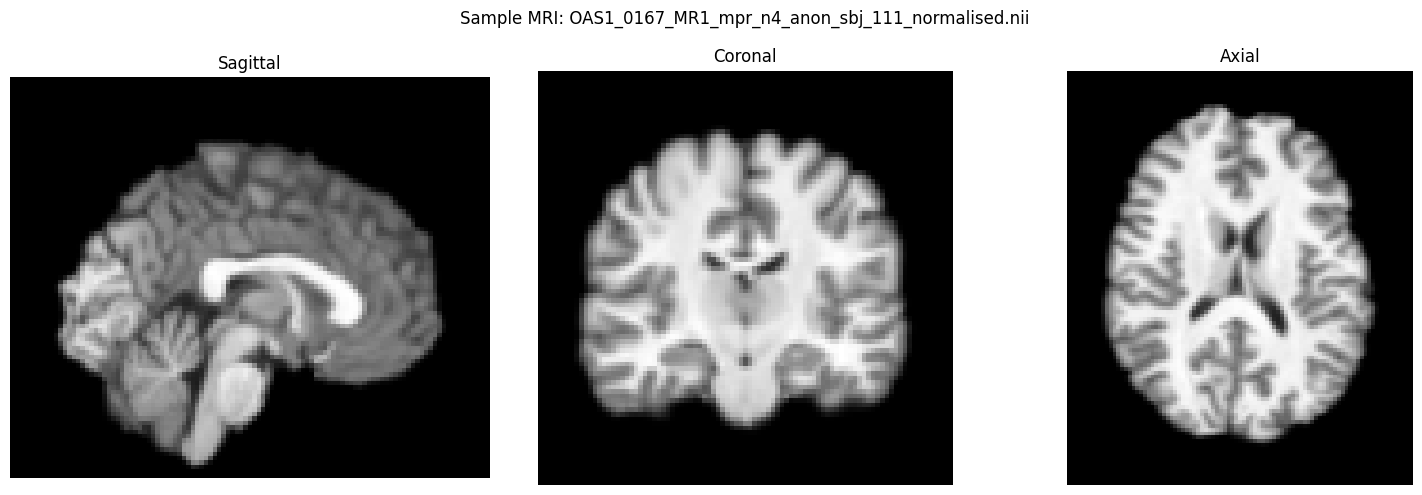

In [25]:
# ============================================================
# 18. VISUALIZE MRI IN THREE ORTHOGONAL PLANES
# ============================================================

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

mri_path = master_df.iloc[0]["MRI_Path"]

img = nib.load(mri_path)
volume = img.get_fdata()

# Middle slices
sagittal_idx = volume.shape[0] // 2
coronal_idx = volume.shape[1] // 2
axial_idx = volume.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sagittal
axes[0].imshow(
    np.rot90(volume[sagittal_idx, :, :]),
    cmap="gray"
)
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Coronal
axes[1].imshow(
    np.rot90(volume[:, coronal_idx, :]),
    cmap="gray"
)
axes[1].set_title("Coronal")
axes[1].axis("off")

# Axial
axes[2].imshow(
    np.rot90(volume[:, :, axial_idx]),
    cmap="gray"
)
axes[2].set_title("Axial")
axes[2].axis("off")

plt.suptitle(
    f"Sample MRI: {Path(mri_path).name}",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 18B. TEST BRAIN-REGION INTENSITY NORMALIZATION
# ============================================================

volume = volume.astype(np.float32)

# Brain/non-background region
brain_mask = volume > 0

brain_values = volume[brain_mask]

mean_intensity = brain_values.mean()
std_intensity = brain_values.std()

normalized_volume = np.zeros_like(volume)

normalized_volume[brain_mask] = (
    (brain_values - mean_intensity) /
    (std_intensity + 1e-8)
)

print("Original:")
print(" Mean:", mean_intensity)
print(" Std :", std_intensity)

print("\nNormalized:")
print(" Mean:", normalized_volume[brain_mask].mean())
print(" Std :", normalized_volume[brain_mask].std())
print(" Min :", normalized_volume[brain_mask].min())
print(" Max :", normalized_volume[brain_mask].max())

Original:
 Mean: 0.6524811
 Std : 0.30314535

Normalized:
 Mean: 3.3349107e-07
 Std : 1.0
 Min : -2.1523705
 Max : 3.9155679


# Creation of MRI Preprocessing Function 

In [27]:
# ============================================================
# 19. MRI PREPROCESSING FUNCTION
# ============================================================

import nibabel as nib
import numpy as np

def preprocess_mri(mri_path):
    """
    Load and preprocess a normalized OASIS MRI volume.

    Returns:
        volume: float32 array with shape (1, 91, 109, 91)
    """

    # Load MRI
    img = nib.load(mri_path)
    volume = img.get_fdata().astype(np.float32)

    # Create brain/non-background mask
    brain_mask = volume > 0

    # Safety check
    if brain_mask.sum() == 0:
        raise ValueError(f"No non-zero voxels found: {mri_path}")

    # Extract brain intensities
    brain_values = volume[brain_mask]

    # Robust intensity clipping
    lower = np.percentile(brain_values, 1)
    upper = np.percentile(brain_values, 99)

    volume = np.clip(volume, lower, upper)

    # Recalculate brain values after clipping
    brain_values = volume[brain_mask]

    # Z-score normalization
    mean = brain_values.mean()
    std = brain_values.std()

    normalized = np.zeros_like(volume)

    normalized[brain_mask] = (
        (brain_values - mean) /
        (std + 1e-8)
    )

    # Add channel dimension for PyTorch
    normalized = normalized[np.newaxis, ...]

    return normalized.astype(np.float32)

# Test the function

In [28]:
# ============================================================
# 19B. TEST PREPROCESSING
# ============================================================

sample_path = master_df.iloc[0]["MRI_Path"]

processed = preprocess_mri(sample_path)

print("Processed shape:", processed.shape)
print("Data type:", processed.dtype)

# Remove channel dimension for statistics
processed_volume = processed[0]

brain_mask = processed_volume != 0
brain_values = processed_volume[brain_mask]

print("\nProcessed brain statistics:")
print("Mean:", brain_values.mean())
print("Std :", brain_values.std())
print("Min :", brain_values.min())
print("Max :", brain_values.max())

print("\nNaN:", np.isnan(processed).sum())
print("Inf:", np.isinf(processed).sum())

Processed shape: (1, 91, 109, 91)
Data type: float32

Processed brain statistics:
Mean: 1.8630786e-09
Std : 1.0
Min : -2.1510987
Max : 1.433717

NaN: 0
Inf: 0


# Visualization of processed MRI

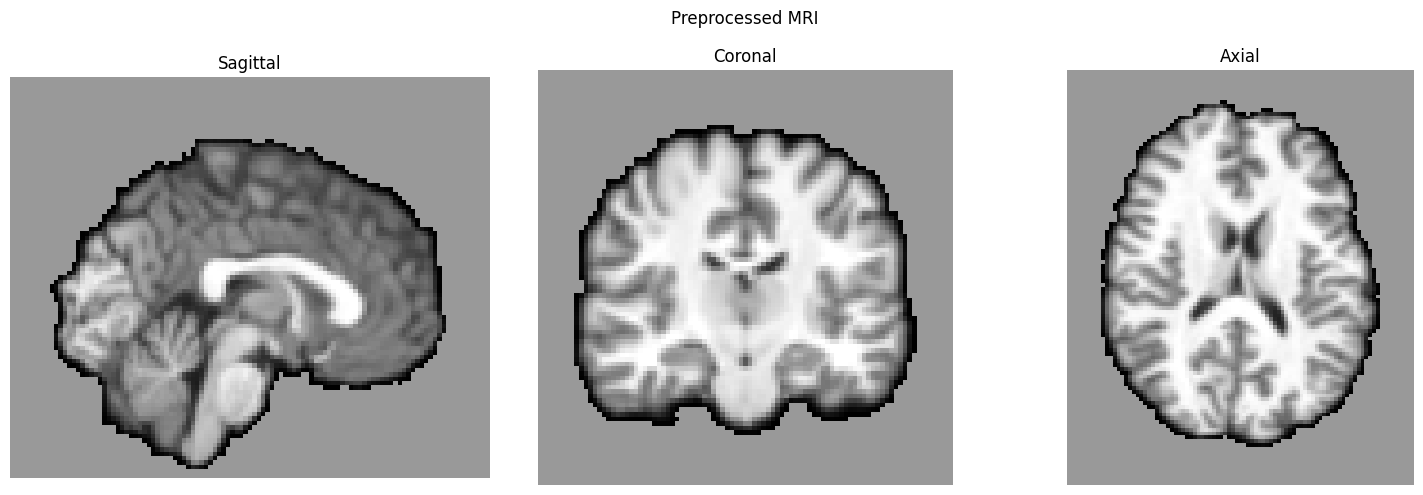

In [29]:
# ============================================================
# 19C. VISUALIZE PREPROCESSED MRI
# ============================================================

volume = processed[0]

sagittal_idx = volume.shape[0] // 2
coronal_idx = volume.shape[1] // 2
axial_idx = volume.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    np.rot90(volume[sagittal_idx, :, :]),
    cmap="gray"
)
axes[0].set_title("Sagittal")
axes[0].axis("off")

axes[1].imshow(
    np.rot90(volume[:, coronal_idx, :]),
    cmap="gray"
)
axes[1].set_title("Coronal")
axes[1].axis("off")

axes[2].imshow(
    np.rot90(volume[:, :, axial_idx]),
    cmap="gray"
)
axes[2].set_title("Axial")
axes[2].axis("off")

plt.suptitle("Preprocessed MRI")
plt.tight_layout()
plt.show()

# Build the PyTorch Dataset

In [30]:
# ============================================================
# 20. PYTORCH DATASET
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

class OASISDataset(Dataset):

    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        # Preprocess MRI
        volume = preprocess_mri(row["MRI_Path"])

        # Convert to PyTorch tensor
        volume = torch.from_numpy(volume)

        # Binary label
        label = torch.tensor(
            row["Label"],
            dtype=torch.float32
        )

        return volume, label

In [31]:
# ============================================================
# 20B. CREATE DATASET SPLITS
# ============================================================

train_df = master_df[master_df["Split"] == "train"].copy()
val_df   = master_df[master_df["Split"] == "val"].copy()
test_df  = master_df[master_df["Split"] == "test"].copy()

print("Train MRI records:", len(train_df))
print("Validation MRI records:", len(val_df))
print("Test MRI records:", len(test_df))

print("\nTrain labels:")
print(train_df["Diagnosis"].value_counts())

print("\nValidation labels:")
print(val_df["Diagnosis"].value_counts())

print("\nTest labels:")
print(test_df["Diagnosis"].value_counts())

Train MRI records: 301
Validation MRI records: 67
Test MRI records: 68

Train labels:
Diagnosis
Non-Demented    231
Dementia         70
Name: count, dtype: int64

Validation labels:
Diagnosis
Non-Demented    52
Dementia        15
Name: count, dtype: int64

Test labels:
Diagnosis
Non-Demented    53
Dementia        15
Name: count, dtype: int64


In [32]:
# ============================================================
# 20C. INITIALIZE DATASETS
# ============================================================

train_dataset = OASISDataset(train_df)
val_dataset   = OASISDataset(val_df)
test_dataset  = OASISDataset(test_df)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 301
Validation dataset: 67
Test dataset: 68


# Test one MRI

In [33]:
# ============================================================
# 20D. TEST DATASET
# ============================================================

volume, label = train_dataset[0]

print("Volume shape:", volume.shape)
print("Volume dtype:", volume.dtype)
print("Label:", label)
print("Label dtype:", label.dtype)

Volume shape: torch.Size([1, 91, 109, 91])
Volume dtype: torch.float32
Label: tensor(0.)
Label dtype: torch.float32


# Creation of dataloader

As the training set is imbalanced, we would use WeightedRandomSampler rather than simply duplicating dementia scans. This makes the model see the two classes more evenly during training without changing validation/test distributions.

In [34]:
# ============================================================
# 21. CREATE BALANCED TRAINING DATALOADER
# ============================================================

from torch.utils.data import DataLoader, WeightedRandomSampler

# Get training labels
train_labels = train_df["Label"].values.astype(int)

# Count samples in each class
class_counts = np.bincount(train_labels)

print("Class counts:")
print("Non-Demented (0):", class_counts[0])
print("Dementia (1):", class_counts[1])

# Weight for each class
class_weights = 1.0 / class_counts

# Weight for each training sample
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

print("\nClass weights:")
print("Non-Demented:", class_weights[0])
print("Dementia:", class_weights[1])

Class counts:
Non-Demented (0): 231
Dementia (1): 70

Class weights:
Non-Demented: 0.004329004329004329
Dementia: 0.014285714285714285


In [35]:
# ============================================================
# 21B. CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 151
Validation batches: 34
Test batches: 34


In [36]:
# ============================================================
# 21C. TEST DATALOADER
# ============================================================

batch_volumes, batch_labels = next(iter(train_loader))

print("Batch volume shape:", batch_volumes.shape)
print("Batch labels shape:", batch_labels.shape)

print("Batch volume dtype:", batch_volumes.dtype)
print("Batch labels:", batch_labels)

Batch volume shape: torch.Size([2, 1, 91, 109, 91])
Batch labels shape: torch.Size([2])
Batch volume dtype: torch.float32
Batch labels: tensor([0., 1.])


In [37]:
# ============================================================
# 22. CHECK GPU AVAILABILITY
# ============================================================

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
else:
    print("No GPU detected.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU count: 2


In [38]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [39]:
# ============================================================
# 22. SET COMPUTATION DEVICE
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Using device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


# Build our baseline 3D CNN

In [40]:
# ============================================================
# 23. COMPACT 3D CNN
# ============================================================

import torch.nn as nn

class OASIS3DCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            # Block 2
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            # Block 3
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            # Block 4
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            # Global Average Pooling
            nn.AdaptiveAvgPool3d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [41]:
print("master_df exists:", "master_df" in globals())

print("Split column exists:", "Split" in master_df.columns)
print("Label column exists:", "Label" in master_df.columns)

master_df exists: True
Split column exists: True
Label column exists: True


In [42]:
train_df = master_df[master_df["Split"] == "train"].copy()
val_df   = master_df[master_df["Split"] == "val"].copy()
test_df  = master_df[master_df["Split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain labels:")
print(train_df["Label"].value_counts())

print("\nValidation labels:")
print(val_df["Label"].value_counts())

print("\nTest labels:")
print(test_df["Label"].value_counts())

Train: 301
Validation: 67
Test: 68

Train labels:
Label
0    231
1     70
Name: count, dtype: int64

Validation labels:
Label
0    52
1    15
Name: count, dtype: int64

Test labels:
Label
0    53
1    15
Name: count, dtype: int64


In [43]:
train_dataset = OASISDataset(train_df)
val_dataset   = OASISDataset(val_df)
test_dataset  = OASISDataset(test_df)

print(len(train_dataset), len(val_dataset), len(test_dataset))

301 67 68


In [44]:
from torch.utils.data import DataLoader, WeightedRandomSampler

BATCH_SIZE = 2

train_labels = train_df["Label"].values.astype(int)

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 151
Val batches: 34
Test batches: 34


In [45]:
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class OASIS3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(1, 16, 3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(16, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool3d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = OASIS3DCNN().to(DEVICE)

print("Using device:", DEVICE)
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Using device: cuda
Trainable parameters: 291585


In [46]:
# ============================================================
# 23C. TEST FORWARD PASS
# ============================================================

model.eval()

with torch.no_grad():

    sample_batch, sample_labels = next(iter(train_loader))

    sample_batch = sample_batch.to(DEVICE)

    output = model(sample_batch)

print("Input shape :", sample_batch.shape)
print("Output shape:", output.shape)
print("Output:", output)

Input shape : torch.Size([2, 1, 91, 109, 91])
Output shape: torch.Size([2, 1])
Output: tensor([[-0.0217],
        [-0.0215]], device='cuda:0')


# Loss function and optimizer

In [47]:
import torch.optim as optim

# Binary classification loss
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


# Quick loss test

In [48]:
model.train()

sample_batch, sample_labels = next(iter(train_loader))

sample_batch = sample_batch.to(DEVICE)
sample_labels = sample_labels.to(DEVICE).unsqueeze(1)

outputs = model(sample_batch)

loss = criterion(outputs, sample_labels)

print("Outputs shape:", outputs.shape)
print("Labels shape:", sample_labels.shape)
print("Loss:", loss.item())

Outputs shape: torch.Size([2, 1])
Labels shape: torch.Size([2, 1])
Loss: 0.6400148272514343


# Setting of training configuration 

In [49]:
NUM_EPOCHS = 30
PATIENCE = 7

best_val_auc = 0.0
patience_counter = 0

print("Epochs:", NUM_EPOCHS)
print("Early stopping patience:", PATIENCE)

Epochs: 30
Early stopping patience: 7


In [50]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import copy
import time

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": [],
    "train_acc": [],
    "val_acc": []
}

best_model_state = None

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # =========================================================
    # TRAINING
    # =========================================================
    model.train()

    train_losses = []
    train_probs = []
    train_targets = []

    for volumes, labels in train_loader:

        volumes = volumes.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(volumes)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        probs = torch.sigmoid(outputs)

        train_probs.extend(probs.detach().cpu().numpy().ravel())
        train_targets.extend(labels.detach().cpu().numpy().ravel())

    # Training metrics
    train_loss = np.mean(train_losses)

    train_preds = (np.array(train_probs) >= 0.5).astype(int)

    train_auc = roc_auc_score(train_targets, train_probs)
    train_acc = accuracy_score(train_targets, train_preds)

    # =========================================================
    # VALIDATION
    # =========================================================
    model.eval()

    val_losses = []
    val_probs = []
    val_targets = []

    with torch.no_grad():

        for volumes, labels in val_loader:

            volumes = volumes.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).unsqueeze(1)

            outputs = model(volumes)

            loss = criterion(outputs, labels)

            val_losses.append(loss.item())

            probs = torch.sigmoid(outputs)

            val_probs.extend(probs.cpu().numpy().ravel())
            val_targets.extend(labels.cpu().numpy().ravel())

    # Validation metrics
    val_loss = np.mean(val_losses)

    val_preds = (np.array(val_probs) >= 0.5).astype(int)

    val_auc = roc_auc_score(val_targets, val_probs)
    val_acc = accuracy_score(val_targets, val_preds)

    # =========================================================
    # SAVE HISTORY
    # =========================================================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train AUC: {train_auc:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    # =========================================================
    # EARLY STOPPING
    # =========================================================
    if val_auc > best_val_auc:

        best_val_auc = val_auc
        patience_counter = 0

        best_model_state = copy.deepcopy(model.state_dict())

        print(f"  ✓ New best validation AUC: {best_val_auc:.4f}")

    else:

        patience_counter += 1

        print(
            f"  No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

        if patience_counter >= PATIENCE:

            print("\nEarly stopping triggered.")
            break

print("\nTraining finished.")
print("Best validation AUC:", round(best_val_auc, 4))

Epoch [01/30] | Train Loss: 0.6634 | Val Loss: 1.0702 | Train AUC: 0.6775 | Val AUC: 0.9051 | Train Acc: 0.6013 | Val Acc: 0.2239 | Time: 19.2s
  ✓ New best validation AUC: 0.9051
Epoch [02/30] | Train Loss: 0.5635 | Val Loss: 0.8500 | Train AUC: 0.7980 | Val AUC: 0.9064 | Train Acc: 0.7143 | Val Acc: 0.4776 | Time: 10.7s
  ✓ New best validation AUC: 0.9064
Epoch [03/30] | Train Loss: 0.5755 | Val Loss: 2.4190 | Train AUC: 0.7800 | Val AUC: 0.9103 | Train Acc: 0.6811 | Val Acc: 0.2239 | Time: 9.2s
  ✓ New best validation AUC: 0.9103
Epoch [04/30] | Train Loss: 0.5596 | Val Loss: 1.1354 | Train AUC: 0.7865 | Val AUC: 0.9077 | Train Acc: 0.6910 | Val Acc: 0.3731 | Time: 8.7s
  No improvement (1/7)
Epoch [05/30] | Train Loss: 0.5544 | Val Loss: 0.4252 | Train AUC: 0.7911 | Val AUC: 0.8974 | Train Acc: 0.7110 | Val Acc: 0.8060 | Time: 8.8s
  No improvement (2/7)
Epoch [06/30] | Train Loss: 0.5322 | Val Loss: 0.9188 | Train AUC: 0.8110 | Val AUC: 0.8987 | Train Acc: 0.7276 | Val Acc: 0.5821

In [51]:
# Restore the model from the best validation AUC epoch
model.load_state_dict(best_model_state)

print("Best validation AUC:", best_val_auc)
print("Best model restored.")

Best validation AUC: 0.9102564102564102
Best model restored.


# Generate test predictions

In [52]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

model.eval()

test_probs = []
test_targets = []

with torch.no_grad():

    for volumes, labels in test_loader:

        volumes = volumes.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(volumes)

        probs = torch.sigmoid(outputs).squeeze(1)

        test_probs.extend(probs.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

test_probs = np.array(test_probs)
test_targets = np.array(test_targets).astype(int)

# Default classification threshold
test_preds = (test_probs >= 0.5).astype(int)

print("Number of test samples:", len(test_targets))
print("Predictions generated successfully.")
print("Probability range:",
      round(test_probs.min(), 4),
      "to",
      round(test_probs.max(), 4))

Number of test samples: 68
Predictions generated successfully.
Probability range: 0.8106 to 0.9964


# Test-set performance

In [53]:
# ============================================================
# TEST METRICS
# ============================================================

test_auc = roc_auc_score(test_targets, test_probs)

test_pr_auc = average_precision_score(
    test_targets,
    test_probs
)

test_accuracy = accuracy_score(
    test_targets,
    test_preds
)

test_precision = precision_score(
    test_targets,
    test_preds,
    zero_division=0
)

test_recall = recall_score(
    test_targets,
    test_preds,
    zero_division=0
)

test_f1 = f1_score(
    test_targets,
    test_preds,
    zero_division=0
)

cm = confusion_matrix(
    test_targets,
    test_preds
)

tn, fp, fn, tp = cm.ravel()

test_specificity = tn / (tn + fp)

print("=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)

print(f"ROC-AUC      : {test_auc:.4f}")
print(f"PR-AUC       : {test_pr_auc:.4f}")
print(f"Accuracy     : {test_accuracy:.4f}")
print(f"Precision    : {test_precision:.4f}")
print(f"Sensitivity  : {test_recall:.4f}")
print(f"Specificity  : {test_specificity:.4f}")
print(f"F1-score     : {test_f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TEST SET PERFORMANCE
ROC-AUC      : 0.8805
PR-AUC       : 0.6765
Accuracy     : 0.2206
Precision    : 0.2206
Sensitivity  : 1.0000
Specificity  : 0.0000
F1-score     : 0.3614

Confusion Matrix:
[[ 0 53]
 [ 0 15]]

TN: 0
FP: 53
FN: 0
TP: 15


# Check subject-level test predictions

In [54]:
# Create a copy of the test dataframe
test_results = test_df.copy()

# Add predictions
test_results["Probability"] = test_probs
test_results["Prediction"] = test_preds

print("Test MRI records:", len(test_results))
print("Unique test subjects:", test_results["Subject_ID"].nunique())

print("\nSubjects with multiple MRI sessions:")
print(
    test_results["Subject_ID"]
    .value_counts()
    .loc[lambda x: x > 1]
)

Test MRI records: 68
Unique test subjects: 63

Subjects with multiple MRI sessions:
Subject_ID
OAS1_0395    2
OAS1_0353    2
OAS1_0249    2
OAS1_0156    2
OAS1_0379    2
Name: count, dtype: int64


# Aggregate the two MRI sessions per subject
We'll average the predicted probabilities for subjects who have multiple sessions. For subjects with only one scan, their probability remains unchanged.

In [55]:
# ============================================================
# SUBJECT-LEVEL TEST RESULTS
# ============================================================

subject_results = (
    test_results
    .groupby("Subject_ID")
    .agg(
        Label=("Label", "first"),
        Probability=("Probability", "mean"),
        Num_MRI=("MRI_ID", "count")
    )
    .reset_index()
)

# Classification using the same 0.5 threshold
subject_results["Prediction"] = (
    subject_results["Probability"] >= 0.5
).astype(int)

print("Unique subjects:", len(subject_results))

print("\nSubject label distribution:")
print(subject_results["Label"].value_counts())

print("\nMRI sessions per subject:")
print(subject_results["Num_MRI"].value_counts().sort_index())

print("\nFirst 10 subject-level results:")
print(subject_results.head(10))

Unique subjects: 63

Subject label distribution:
Label
0    48
1    15
Name: count, dtype: int64

MRI sessions per subject:
Num_MRI
1    58
2     5
Name: count, dtype: int64

First 10 subject-level results:
  Subject_ID  Label  Probability  Num_MRI  Prediction
0  OAS1_0015      1     0.987520        1           1
1  OAS1_0023      1     0.988197        1           1
2  OAS1_0030      0     0.987058        1           1
3  OAS1_0032      0     0.993668        1           1
4  OAS1_0034      0     0.893273        1           1
5  OAS1_0050      0     0.864537        1           1
6  OAS1_0054      0     0.845648        1           1
7  OAS1_0060      1     0.985770        1           1
8  OAS1_0062      0     0.976485        1           1
9  OAS1_0066      1     0.925500        1           1


# Calculate subject-level metrics

In [56]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

subject_targets = subject_results["Label"].values.astype(int)
subject_probs = subject_results["Probability"].values
subject_preds = subject_results["Prediction"].values.astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

subject_auc = roc_auc_score(
    subject_targets,
    subject_probs
)

subject_pr_auc = average_precision_score(
    subject_targets,
    subject_probs
)

subject_accuracy = accuracy_score(
    subject_targets,
    subject_preds
)

subject_precision = precision_score(
    subject_targets,
    subject_preds,
    zero_division=0
)

subject_sensitivity = recall_score(
    subject_targets,
    subject_preds,
    zero_division=0
)

subject_f1 = f1_score(
    subject_targets,
    subject_preds,
    zero_division=0
)

cm_subject = confusion_matrix(
    subject_targets,
    subject_preds
)

tn, fp, fn, tp = cm_subject.ravel()

subject_specificity = tn / (tn + fp)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 55)
print("SUBJECT-LEVEL TEST PERFORMANCE")
print("=" * 55)

print(f"ROC-AUC      : {subject_auc:.4f}")
print(f"PR-AUC       : {subject_pr_auc:.4f}")
print(f"Accuracy     : {subject_accuracy:.4f}")
print(f"Precision    : {subject_precision:.4f}")
print(f"Sensitivity  : {subject_sensitivity:.4f}")
print(f"Specificity  : {subject_specificity:.4f}")
print(f"F1-score     : {subject_f1:.4f}")

print("\nConfusion Matrix:")
print(cm_subject)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

SUBJECT-LEVEL TEST PERFORMANCE
ROC-AUC      : 0.8708
PR-AUC       : 0.6777
Accuracy     : 0.2381
Precision    : 0.2381
Sensitivity  : 1.0000
Specificity  : 0.0000
F1-score     : 0.3846

Confusion Matrix:
[[ 0 48]
 [ 0 15]]

TN: 0
FP: 48
FN: 0
TP: 15


# Evaluation Curves

Training/Validation curves

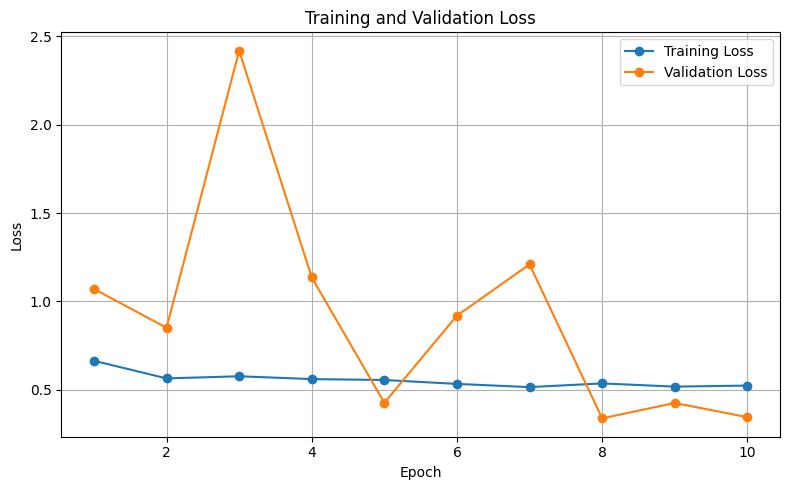

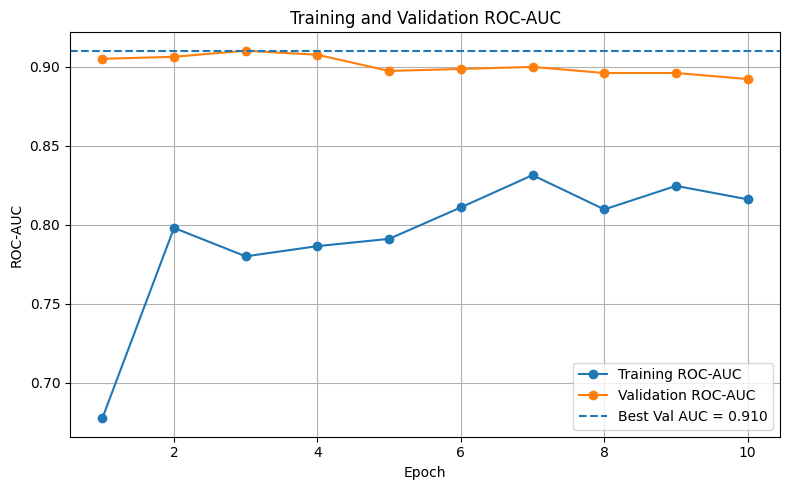

In [57]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# ============================================================
# 1. LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 2. ROC-AUC CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_auc"],
    marker="o",
    label="Training ROC-AUC"
)

plt.plot(
    epochs,
    history["val_auc"],
    marker="o",
    label="Validation ROC-AUC"
)

plt.axhline(
    y=best_val_auc,
    linestyle="--",
    label=f"Best Val AUC = {best_val_auc:.3f}"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training and Validation ROC-AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Subject-level ROC curve

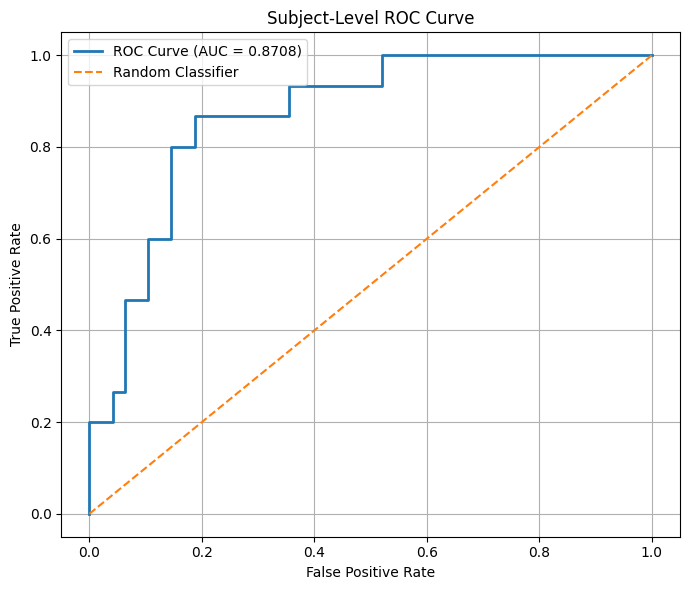

Subject-level ROC-AUC: 0.8708


In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Subject-level test targets and probabilities
subject_targets = subject_results["Label"].values
subject_probs = subject_results["Probability"].values

# ROC curve
fpr, tpr, thresholds = roc_curve(
    subject_targets,
    subject_probs
)

roc_auc = roc_auc_score(
    subject_targets,
    subject_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Subject-Level ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Subject-level ROC-AUC: {roc_auc:.4f}")

# Subject-level Precision–Recall curve

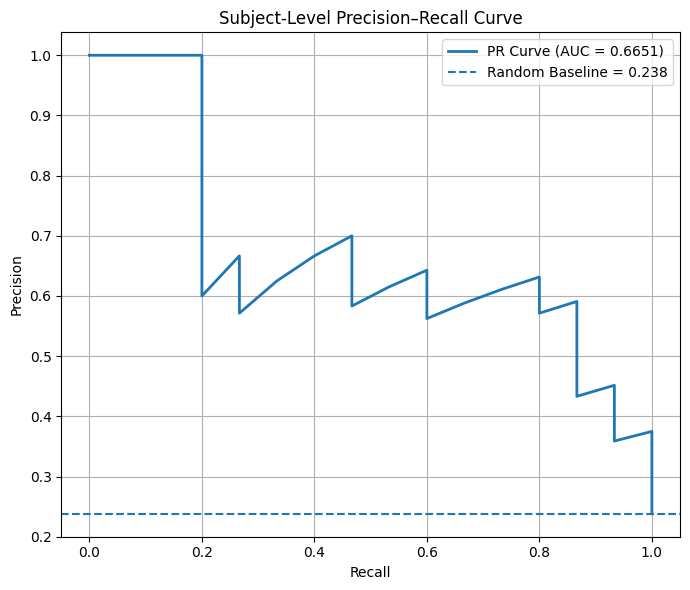

Subject-level PR-AUC: 0.6651
Positive-class prevalence: 0.2381


In [59]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(
    subject_targets,
    subject_probs
)

pr_auc = auc(recall, precision)

# Positive-class prevalence
baseline = subject_targets.mean()

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR Curve (AUC = {pr_auc:.4f})"
)

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Random Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Subject-Level Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Subject-level PR-AUC: {pr_auc:.4f}")
print(f"Positive-class prevalence: {baseline:.4f}")

# Subject Level Confusion Matrix

Number of subjects: 63
True labels: [48 15]
Predicted labels: [ 0 63]

Confusion Matrix:
[[ 0 48]
 [ 0 15]]


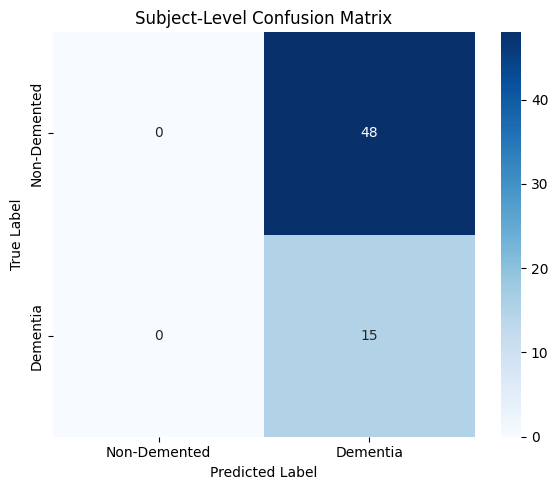

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Recreate directly from the final subject-level dataframe
subject_targets = subject_results["Label"].to_numpy()
subject_probs = subject_results["Probability"].to_numpy()

# Threshold = 0.5
subject_predictions = (subject_probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(
    subject_targets,
    subject_predictions,
    labels=[0, 1]
)

print("Number of subjects:", len(subject_targets))
print("True labels:", np.bincount(subject_targets))
print("Predicted labels:", np.bincount(subject_predictions))
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Demented", "Dementia"],
    yticklabels=["Non-Demented", "Dementia"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Subject-Level Confusion Matrix")

plt.tight_layout()
plt.show()

In [61]:
print("Probability statistics:")
print(subject_results["Probability"].describe())

print("\nMinimum probability:")
print(subject_results["Probability"].min())

print("\nMaximum probability:")
print(subject_results["Probability"].max())

print("\nNumber of probabilities < 0.5:")
print((subject_results["Probability"] < 0.5).sum())

print("\nFirst 20 subjects:")
print(
    subject_results[
        ["Subject_ID", "Label", "Probability", "Prediction"]
    ].head(20).to_string(index=False)
)

Probability statistics:
count    63.000000
mean      0.939585
std       0.054900
min       0.815578
25%       0.900149
50%       0.964141
75%       0.986507
max       0.996398
Name: Probability, dtype: float64

Minimum probability:
0.8155776858329773

Maximum probability:
0.9963977336883545

Number of probabilities < 0.5:
0

First 20 subjects:
Subject_ID  Label  Probability  Prediction
 OAS1_0015      1     0.987520           1
 OAS1_0023      1     0.988197           1
 OAS1_0030      0     0.987058           1
 OAS1_0032      0     0.993668           1
 OAS1_0034      0     0.893273           1
 OAS1_0050      0     0.864537           1
 OAS1_0054      0     0.845648           1
 OAS1_0060      1     0.985770           1
 OAS1_0062      0     0.976485           1
 OAS1_0066      1     0.925500           1
 OAS1_0074      0     0.920353           1
 OAS1_0075      0     0.988406           1
 OAS1_0077      0     0.898689           1
 OAS1_0079      0     0.917528           1
 OAS1_009

In [62]:
print("TEST_RESULTS")
print("=" * 50)

print("Shape:", test_results.shape)

print("\nProbability statistics:")
print(test_results["Probability"].describe())

print("\nProbability < 0.5:")
print((test_results["Probability"] < 0.5).sum())

print("\nFirst 15 test predictions:")
print(
    test_results[
        ["Subject_ID", "MRI_ID", "Label", "Probability", "Prediction"]
    ].head(15).to_string(index=False)
)

TEST_RESULTS
Shape: (68, 19)

Probability statistics:
count    68.000000
mean      0.936083
std       0.056336
min       0.810561
25%       0.897778
50%       0.953710
75%       0.985839
max       0.996398
Name: Probability, dtype: float64

Probability < 0.5:
0

First 15 test predictions:
Subject_ID        MRI_ID  Label  Probability  Prediction
 OAS1_0271 OAS1_0271_MR1      0     0.981398           1
 OAS1_0307 OAS1_0307_MR1      1     0.992988           1
 OAS1_0186 OAS1_0186_MR1      0     0.991935           1
 OAS1_0212 OAS1_0212_MR1      0     0.994149           1
 OAS1_0130 OAS1_0130_MR1      0     0.967812           1
 OAS1_0448 OAS1_0448_MR1      0     0.823132           1
 OAS1_0122 OAS1_0122_MR1      1     0.993343           1
 OAS1_0113 OAS1_0113_MR1      0     0.983969           1
 OAS1_0395 OAS1_0395_MR2      0     0.947907           1
 OAS1_0457 OAS1_0457_MR1      0     0.974626           1
 OAS1_0274 OAS1_0274_MR1      0     0.964141           1
 OAS1_0304 OAS1_0304_MR1  

In [63]:
# Check the current model outputs before sigmoid

model.eval()

raw_logits = []
true_labels = []

with torch.no_grad():
    for volumes, labels in test_loader:
        volumes = volumes.to(DEVICE)

        outputs = model(volumes)

        raw_logits.extend(outputs.squeeze(1).cpu().numpy())
        true_labels.extend(labels.numpy())

raw_logits = np.array(raw_logits)
true_labels = np.array(true_labels)

print("Raw logit statistics:")
print(f"Min:    {raw_logits.min():.4f}")
print(f"Max:    {raw_logits.max():.4f}")
print(f"Mean:   {raw_logits.mean():.4f}")
print(f"Median: {np.median(raw_logits):.4f}")

print("\nNumber of positive logits:", (raw_logits > 0).sum())
print("Number of negative logits:", (raw_logits < 0).sum())

print("\nFirst 15 logits:")
print(raw_logits[:15])

Raw logit statistics:
Min:    1.4537
Max:    5.6226
Mean:   3.2066
Median: 3.0294

Number of positive logits: 68
Number of negative logits: 0

First 15 logits:
[3.9657342 4.9531045 4.812093  5.135354  3.4034421 1.537713  5.0053787
 4.117066  2.901221  3.6483254 3.2916286 4.972007  2.5195413 3.344314
 1.8534986]


# Find the optimal threshold on validation data

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

model.eval()

val_probs = []
val_targets = []

with torch.no_grad():
    for volumes, labels in val_loader:
        volumes = volumes.to(DEVICE)

        logits = model(volumes).squeeze(1)
        probs = torch.sigmoid(logits)

        val_probs.extend(probs.cpu().numpy())
        val_targets.extend(labels.numpy())

val_probs = np.array(val_probs)
val_targets = np.array(val_targets)

# ROC curve on VALIDATION set only
fpr, tpr, thresholds = roc_curve(
    val_targets,
    val_probs
)

# Youden's J statistic
youden_j = tpr - fpr

best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

val_auc = roc_auc_score(val_targets, val_probs)

print(f"Validation ROC-AUC: {val_auc:.4f}")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"TPR at threshold: {tpr[best_idx]:.4f}")
print(f"FPR at threshold: {fpr[best_idx]:.4f}")

print("\nValidation probability statistics:")
print(f"Min:    {val_probs.min():.4f}")
print(f"Max:    {val_probs.max():.4f}")
print(f"Mean:   {val_probs.mean():.4f}")
print(f"Median: {np.median(val_probs):.4f}")

Validation ROC-AUC: 0.9103
Optimal threshold: 0.9686
TPR at threshold: 1.0000
FPR at threshold: 0.2692

Validation probability statistics:
Min:    0.8191
Max:    0.9966
Mean:   0.9470
Median: 0.9512


# Apply the validation threshold to the test set

In [65]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Use the threshold selected from VALIDATION data
TEST_THRESHOLD = best_threshold

# Test predictions
test_predictions = (subject_probs >= TEST_THRESHOLD).astype(int)

# Confusion matrix
cm = confusion_matrix(
    subject_targets,
    test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(subject_targets, test_predictions)
precision = precision_score(subject_targets, test_predictions, zero_division=0)
sensitivity = recall_score(subject_targets, test_predictions, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(subject_targets, test_predictions, zero_division=0)

# Threshold-independent metrics
roc_auc = roc_auc_score(subject_targets, subject_probs)
pr_auc = average_precision_score(subject_targets, subject_probs)

print("=" * 55)
print("FINAL SUBJECT-LEVEL TEST RESULTS")
print("=" * 55)

print(f"Decision threshold: {TEST_THRESHOLD:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:              {pr_auc:.4f}")
print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Sensitivity:         {sensitivity:.4f}")
print(f"Specificity:         {specificity:.4f}")
print(f"F1-score:            {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

FINAL SUBJECT-LEVEL TEST RESULTS
Decision threshold: 0.9686
ROC-AUC:            0.8708
PR-AUC:              0.6777
Accuracy:            0.7302
Precision:           0.4643
Sensitivity:         0.8667
Specificity:         0.6875
F1-score:            0.6047

Confusion Matrix:
[[33 15]
 [ 2 13]]

TN: 33
FP: 15
FN: 2
TP: 13


In [66]:
subject_results["Final_Prediction"] = (
    subject_results["Probability"] >= TEST_THRESHOLD
).astype(int)
subject_results.to_csv(
    "subject_test_results.csv",
    index=False
)

print("Saved:", "subject_test_results.csv")

Saved: subject_test_results.csv


In [67]:
test_results.to_csv(
    "mri_test_results.csv",
    index=False
)

print("Saved:", "mri_test_results.csv")

Saved: mri_test_results.csv


In [68]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df.insert(
    0,
    "Epoch",
    range(1, len(history_df) + 1)
)

history_df.to_csv(
    "training_history.csv",
    index=False
)

print("Saved:", "training_history.csv")

Saved: training_history.csv


# saving final metrics

In [69]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Decision Threshold",
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-score",
        "TN",
        "FP",
        "FN",
        "TP"
    ],
    "Value": [
        TEST_THRESHOLD,
        roc_auc,
        pr_auc,
        accuracy,
        precision,
        sensitivity,
        specificity,
        f1,
        tn,
        fp,
        fn,
        tp
    ]
})

metrics_df.to_csv(
    "final_metrics.csv",
    index=False
)

print(metrics_df)

                Metric      Value
0   Decision Threshold   0.968564
1              ROC-AUC   0.870833
2               PR-AUC   0.677668
3             Accuracy   0.730159
4            Precision   0.464286
5          Sensitivity   0.866667
6          Specificity   0.687500
7             F1-score   0.604651
8                   TN  33.000000
9                   FP  15.000000
10                  FN   2.000000
11                  TP  13.000000


In [70]:
torch.save(
    model.state_dict(),
    "OASIS_3DCNN_best_model.pth"
)

print("Model saved.")

Model saved.


In [71]:
torch.save(
    model.state_dict(),
    "OASIS_3DCNN_best_model.pth"
)

print("Model saved.")

Model saved.


# XAI analysis

In [72]:
# Inspect the model architecture
print(model)

# List all Conv3D layers
print("\nConv3D layers:")
for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv3d):
        print(name, "->", layer)

OASIS3DCNN(
  (features): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (13): BatchNorm3

In [73]:

# Grad-CAM target layer
target_layer = model.features[12]

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM target layer:")
print(target_layer)

Grad-CAM target layer:
Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))


# Test the Grad-CAM hooks

In [74]:
# Select one test MRI
sample_idx = 0

volume, label = test_dataset[sample_idx]

# Add batch dimension
volume = volume.unsqueeze(0).to(DEVICE)

model.eval()

# Clear previous gradients
model.zero_grad()

# Forward pass
logit = model(volume)

# Backward pass
logit.backward()

print("MRI input shape:     ", volume.shape)
print("Model output shape:  ", logit.shape)
print("True label:           ", label.item())
print("Predicted probability:", torch.sigmoid(logit).item())

print("\nGrad-CAM activations:")
print("Shape:", activations.shape)

print("\nGrad-CAM gradients:")
print("Shape:", gradients.shape)

MRI input shape:      torch.Size([1, 1, 91, 109, 91])
Model output shape:   torch.Size([1, 1])
True label:            0.0
Predicted probability: 0.9813984036445618

Grad-CAM activations:
Shape: torch.Size([1, 128, 11, 13, 11])

Grad-CAM gradients:
Shape: torch.Size([1, 128, 11, 13, 11])


In [75]:
import torch.nn.functional as F
import numpy as np

# Get activations and gradients
acts = activations.detach()
grads = gradients.detach()

# Grad-CAM channel weights
weights = grads.mean(dim=(2, 3, 4), keepdim=True)

# Weighted combination of feature maps
cam = (weights * acts).sum(dim=1, keepdim=True)

# ReLU: retain positive contributions
cam = F.relu(cam)

# Normalize to [0, 1]
cam_min = cam.min()
cam_max = cam.max()

cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

print("Grad-CAM shape:", cam.shape)
print("Grad-CAM min:", cam.min().item())
print("Grad-CAM max:", cam.max().item())

Grad-CAM shape: torch.Size([1, 1, 11, 13, 11])
Grad-CAM min: 0.0
Grad-CAM max: 0.9999986886978149


# Upsample Grad-CAM

In [76]:
# Upsample Grad-CAM to the original MRI dimensions

cam_upsampled = F.interpolate(
    cam,
    size=(91, 109, 91),
    mode="trilinear",
    align_corners=False
)

cam_upsampled = cam_upsampled.squeeze().cpu().numpy()

print("Upsampled Grad-CAM shape:", cam_upsampled.shape)
print("Min:", cam_upsampled.min())
print("Max:", cam_upsampled.max())

Upsampled Grad-CAM shape: (91, 109, 91)
Min: 0.0
Max: 0.99763393


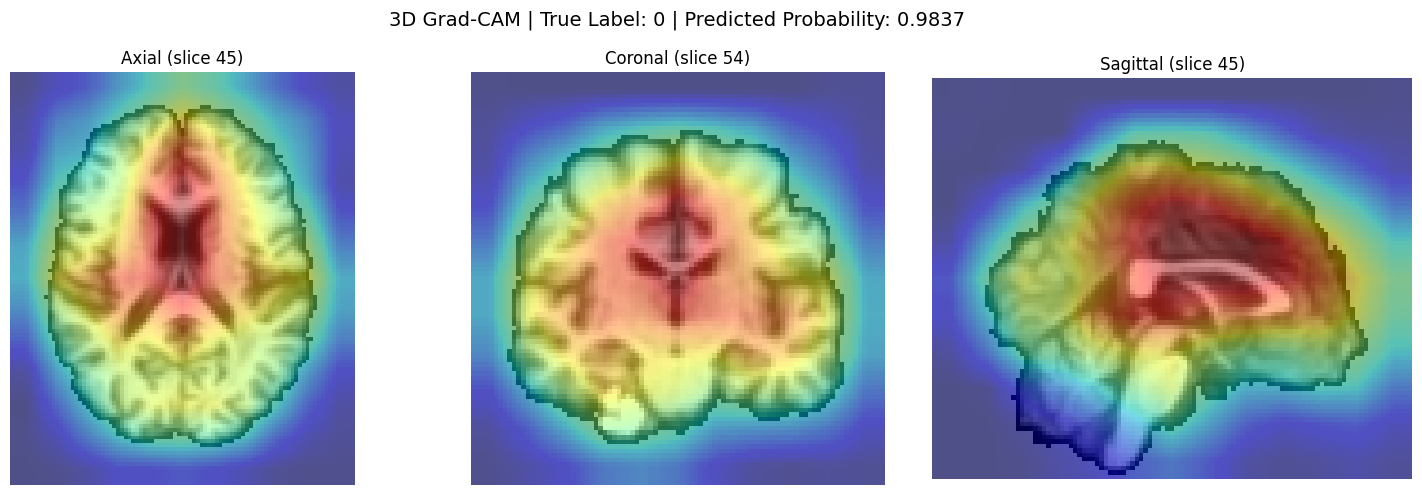

In [80]:
import matplotlib.pyplot as plt

# Original preprocessed MRI volume
mri_volume = volume.squeeze().cpu().numpy()

# Choose central slices
axial_idx = mri_volume.shape[2] // 2
coronal_idx = mri_volume.shape[1] // 2
sagittal_idx = mri_volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axes[0].imshow(
    mri_volume[:, :, axial_idx].T,
    cmap="gray",
    origin="lower"
)
axes[0].imshow(
    cam_upsampled[:, :, axial_idx].T,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)
axes[0].set_title(f"Axial (slice {axial_idx})")
axes[0].axis("off")

# Coronal
axes[1].imshow(
    mri_volume[:, coronal_idx, :].T,
    cmap="gray",
    origin="lower"
)
axes[1].imshow(
    cam_upsampled[:, coronal_idx, :].T,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)
axes[1].set_title(f"Coronal (slice {coronal_idx})")
axes[1].axis("off")

# Sagittal
axes[2].imshow(
    mri_volume[sagittal_idx, :, :].T,
    cmap="gray",
    origin="lower"
)
axes[2].imshow(
    cam_upsampled[sagittal_idx, :, :].T,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)
axes[2].set_title(f"Sagittal (slice {sagittal_idx})")
axes[2].axis("off")

plt.suptitle(
    "3D Grad-CAM | True Label: 0 | Predicted Probability: 0.9837",
    fontsize=14
)


plt.tight_layout()
plt.show()

In [78]:
# Get the sample information again
sample_idx = 0

sample_volume, true_label = test_dataset[sample_idx]

sample_input = sample_volume.unsqueeze(0).to(DEVICE)

model.eval()

with torch.no_grad():
    logit = model(sample_input)
    probability = torch.sigmoid(logit).item()

print("True label:", int(true_label.item()))
print("Predicted probability:", probability)

True label: 0
Predicted probability: 0.9813984036445618


In [79]:
plt.suptitle(
    f"3D Grad-CAM | True Label: {int(true_label.item())} | "
    f"Predicted Probability: {probability:.4f}",
    fontsize=14
)

Text(0.5, 0.98, '3D Grad-CAM | True Label: 0 | Predicted Probability: 0.9814')

<Figure size 640x480 with 0 Axes>

In [81]:
THRESHOLD = 0.9891

subject_results["Prediction"] = (
    subject_results["Probability"] >= THRESHOLD
).astype(int)

# Identify the four cases
TN = subject_results[
    (subject_results["Label"] == 0) &
    (subject_results["Prediction"] == 0)
]

TP = subject_results[
    (subject_results["Label"] == 1) &
    (subject_results["Prediction"] == 1)
]

FP = subject_results[
    (subject_results["Label"] == 0) &
    (subject_results["Prediction"] == 1)
]

FN = subject_results[
    (subject_results["Label"] == 1) &
    (subject_results["Prediction"] == 0)
]

print("TN:", len(TN))
print("TP:", len(TP))
print("FP:", len(FP))
print("FN:", len(FN))

TN: 44
TP: 7
FP: 4
FN: 8


In [82]:
print("\nExample TN:")
print(TN[["Subject_ID", "Label", "Prediction", "Probability"]].head())

print("\nExample TP:")
print(TP[["Subject_ID", "Label", "Prediction", "Probability"]].head())

print("\nExample FP:")
print(FP[["Subject_ID", "Label", "Prediction", "Probability"]].head())

print("\nExample FN:")
print(FN[["Subject_ID", "Label", "Prediction", "Probability"]].head())


Example TN:
  Subject_ID  Label  Prediction  Probability
2  OAS1_0030      0           0     0.987058
4  OAS1_0034      0           0     0.893273
5  OAS1_0050      0           0     0.864537
6  OAS1_0054      0           0     0.845648
8  OAS1_0062      0           0     0.976485

Example TP:
   Subject_ID  Label  Prediction  Probability
20  OAS1_0115      1           1     0.994288
21  OAS1_0122      1           1     0.993343
35  OAS1_0267      1           1     0.996398
38  OAS1_0304      1           1     0.993118
39  OAS1_0307      1           1     0.992988

Example FP:
   Subject_ID  Label  Prediction  Probability
3   OAS1_0032      0           1     0.993668
28  OAS1_0186      0           1     0.991935
31  OAS1_0212      0           1     0.994149
41  OAS1_0338      0           1     0.993272

Example FN:
   Subject_ID  Label  Prediction  Probability
0   OAS1_0015      1           0     0.987520
1   OAS1_0023      1           0     0.988197
7   OAS1_0060      1           0  

In [83]:
# Select a representative True Positive subject
tp_subject = "OAS1_0115"

# Find its MRI record in the test set
tp_rows = test_df[test_df["Subject_ID"] == tp_subject]

print(tp_rows[["Subject_ID", "MRI_ID", "Label", "MRI_Path"]])

    Subject_ID         MRI_ID  Label  \
232  OAS1_0115  OAS1_0115_MR1      1   

                                              MRI_Path  
232  /kaggle/input/datasets/ninadaithal/oasis-1-shi...  


In [84]:
# Take the first MRI for this subject
tp_idx = tp_rows.index[0]

# Convert dataframe index to dataset index
tp_dataset_idx = test_df.reset_index(drop=True).index[
    test_df.reset_index(drop=True)["MRI_ID"] == tp_rows.iloc[0]["MRI_ID"]
][0]

tp_volume, tp_label = test_dataset[tp_dataset_idx]

tp_input = tp_volume.unsqueeze(0).to(DEVICE)

model.eval()

# Forward pass
logit = model(tp_input)
tp_probability = torch.sigmoid(logit).item()

print("Subject:", tp_subject)
print("True label:", int(tp_label.item()))
print("Predicted probability:", tp_probability)

Subject: OAS1_0115
True label: 1
Predicted probability: 0.9942875504493713


In [85]:
# Clear previous gradients
model.zero_grad()

# Use the logit for Grad-CAM
logit = model(tp_input)
logit.backward()

# Retrieve activations and gradients
acts = activations.detach()
grads = gradients.detach()

# Global-average-pool gradients
weights = grads.mean(dim=(2, 3, 4), keepdim=True)

# Grad-CAM
tp_cam = (weights * acts).sum(dim=1, keepdim=True)
tp_cam = F.relu(tp_cam)

# Normalize
tp_cam = (
    tp_cam - tp_cam.min()
) / (
    tp_cam.max() - tp_cam.min() + 1e-8
)

# Upsample to original MRI resolution
tp_cam_upsampled = F.interpolate(
    tp_cam,
    size=(91, 109, 91),
    mode="trilinear",
    align_corners=False
)

tp_cam_upsampled = tp_cam_upsampled.squeeze().cpu().numpy()

print("TP Grad-CAM shape:", tp_cam_upsampled.shape)
print("Min:", tp_cam_upsampled.min())
print("Max:", tp_cam_upsampled.max())

TP Grad-CAM shape: (91, 109, 91)
Min: 0.0
Max: 0.98503613


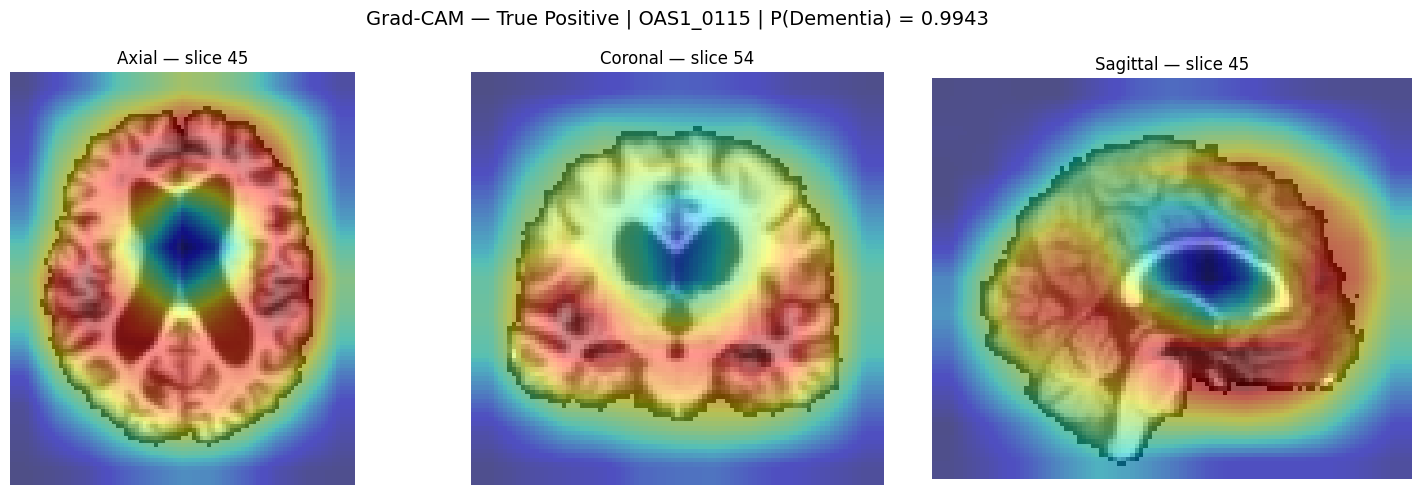

In [86]:
# Get the preprocessed TP MRI volume
tp_mri_volume = tp_volume.squeeze().cpu().numpy()

# Select central slices
axial_idx = tp_mri_volume.shape[2] // 2
coronal_idx = tp_mri_volume.shape[1] // 2
sagittal_idx = tp_mri_volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axes[0].imshow(
    tp_mri_volume[:, :, axial_idx].T,
    cmap="gray",
    origin="lower"
)
axes[0].imshow(
    tp_cam_upsampled[:, :, axial_idx].T,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)
axes[0].set_title(f"Axial — slice {axial_idx}")
axes[0].axis("off")

# Coronal
axes[1].imshow(
    tp_mri_volume[:, coronal_idx, :].T,
    cmap="gray",
    origin="lower"
)
axes[1].imshow(
    tp_cam_upsampled[:, coronal_idx, :].T,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)
axes[1].set_title(f"Coronal — slice {coronal_idx}")
axes[1].axis("off")

# Sagittal
axes[2].imshow(
    tp_mri_volume[sagittal_idx, :, :].T,
    cmap="gray",
    origin="lower"
)
axes[2].imshow(
    tp_cam_upsampled[sagittal_idx, :, :].T,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)
axes[2].set_title(f"Sagittal — slice {sagittal_idx}")
axes[2].axis("off")

plt.suptitle(
    f"Grad-CAM — True Positive | {tp_subject} | "
    f"P(Dementia) = {tp_probability:.4f}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [87]:
def generate_gradcam_for_subject(subject_id):
    # Find subject in test dataframe
    rows = test_df[test_df["Subject_ID"] == subject_id].reset_index(drop=True)

    if len(rows) == 0:
        raise ValueError(f"Subject {subject_id} not found in test set.")

    # Use first MRI if multiple exist
    mri_id = rows.iloc[0]["MRI_ID"]

    # Find corresponding dataset index
    test_reset = test_df.reset_index(drop=True)
    dataset_idx = test_reset.index[
        test_reset["MRI_ID"] == mri_id
    ][0]

    # Load MRI
    volume, label = test_dataset[dataset_idx]
    input_tensor = volume.unsqueeze(0).to(DEVICE)

    # Model evaluation
    model.eval()
    model.zero_grad()

    # Forward pass
    logit = model(input_tensor)
    probability = torch.sigmoid(logit).item()

    # Backward pass
    logit.backward()

    # Grad-CAM
    acts = activations.detach()
    grads = gradients.detach()

    weights = grads.mean(
        dim=(2, 3, 4),
        keepdim=True
    )

    cam = (weights * acts).sum(
        dim=1,
        keepdim=True
    )

    cam = F.relu(cam)

    # Normalize
    cam = (
        cam - cam.min()
    ) / (
        cam.max() - cam.min() + 1e-8
    )

    # Upsample
    cam = F.interpolate(
        cam,
        size=(91, 109, 91),
        mode="trilinear",
        align_corners=False
    )

    cam = cam.squeeze().cpu().numpy()

    return {
        "subject_id": subject_id,
        "volume": volume,
        "label": int(label.item()),
        "probability": probability,
        "cam": cam
    }

In [88]:
tn_result = generate_gradcam_for_subject("OAS1_0030")
fp_result = generate_gradcam_for_subject("OAS1_0032")
fn_result = generate_gradcam_for_subject("OAS1_0015")

print("TN:", tn_result["subject_id"],
      "Label:", tn_result["label"],
      "Probability:", tn_result["probability"])

print("FP:", fp_result["subject_id"],
      "Label:", fp_result["label"],
      "Probability:", fp_result["probability"])

print("FN:", fn_result["subject_id"],
      "Label:", fn_result["label"],
      "Probability:", fn_result["probability"])

print("\nCAM shapes:")
print("TN:", tn_result["cam"].shape)
print("FP:", fp_result["cam"].shape)
print("FN:", fn_result["cam"].shape)

TN: OAS1_0030 Label: 0 Probability: 0.9870581030845642
FP: OAS1_0032 Label: 0 Probability: 0.9936675429344177
FN: OAS1_0015 Label: 1 Probability: 0.9875204563140869

CAM shapes:
TN: (91, 109, 91)
FP: (91, 109, 91)
FN: (91, 109, 91)


In [91]:
def plot_gradcam(result):
    volume = result["volume"].squeeze().cpu().numpy()
    cam = result["cam"]

    subject_id = result["subject_id"]
    label = result["label"]
    probability = result["probability"]

    # Central slices
    axial_idx = volume.shape[2] // 2
    coronal_idx = volume.shape[1] // 2
    sagittal_idx = volume.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Axial
    axes[0].imshow(
        volume[:, :, axial_idx].T,
        cmap="gray",
        origin="lower"
    )
    axes[0].imshow(
        cam[:, :, axial_idx].T,
        cmap="jet",
        alpha=0.45,
        origin="lower"
    )
    axes[0].set_title(f"Axial — slice {axial_idx}")
    axes[0].axis("off")

    # Coronal
    axes[1].imshow(
        volume[:, coronal_idx, :].T,
        cmap="gray",
        origin="lower"
    )
    axes[1].imshow(
        cam[:, coronal_idx, :].T,
        cmap="jet",
        alpha=0.45,
        origin="lower"
    )
    axes[1].set_title(f"Coronal — slice {coronal_idx}")
    axes[1].axis("off")

    # Sagittal
    axes[2].imshow(
        volume[sagittal_idx, :, :].T,
        cmap="gray",
        origin="lower"
    )
    axes[2].imshow(
        cam[sagittal_idx, :, :].T,
        cmap="jet",
        alpha=0.45,
        origin="lower"
    )
    axes[2].set_title(f"Sagittal — slice {sagittal_idx}")
    axes[2].axis("off")

    case_type = {
        (0, 0): "TN",
        (1, 1): "TP",
        (0, 1): "FP",
        (1, 0): "FN"
    }[(label, int(probability >= 0.9891))]

    plt.suptitle(
        f"{case_type} | {subject_id} | "
        f"True: {label} | P(Dementia): {probability:.4f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

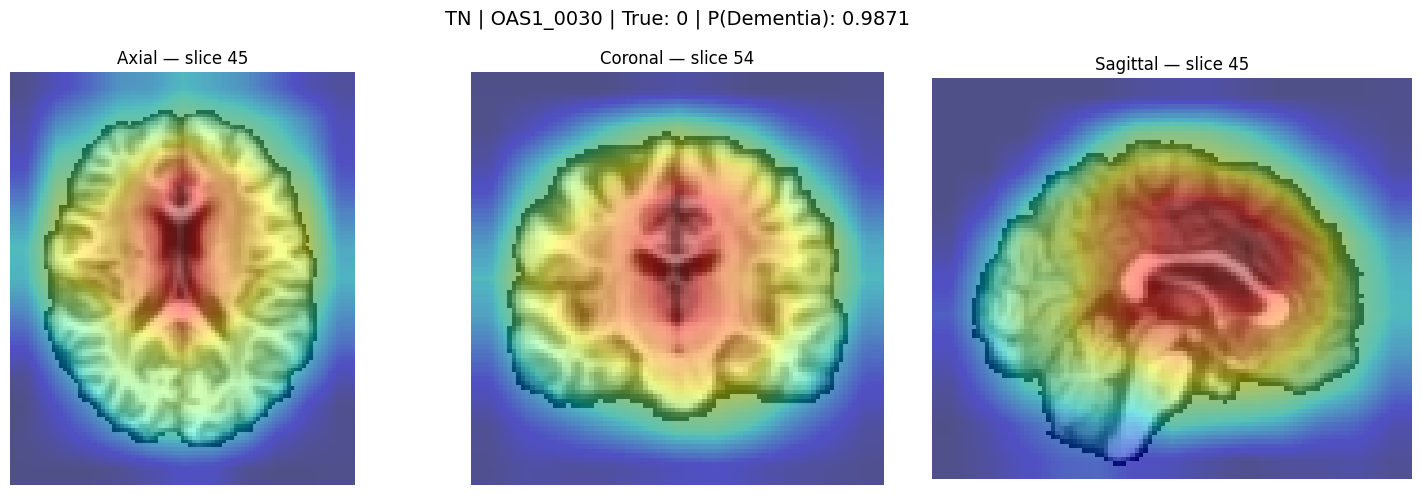

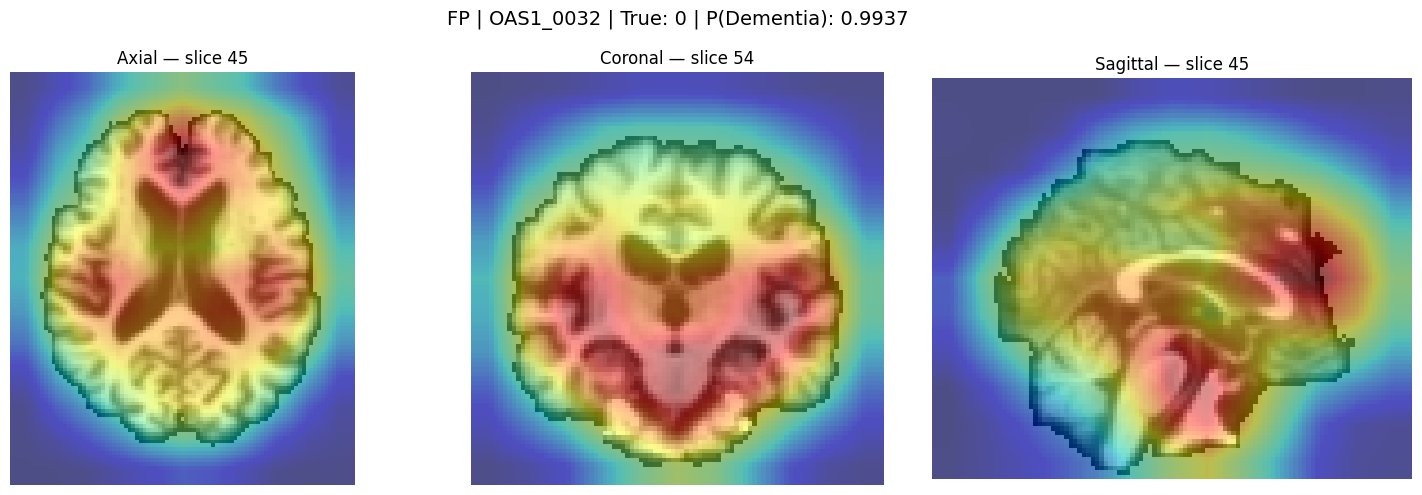

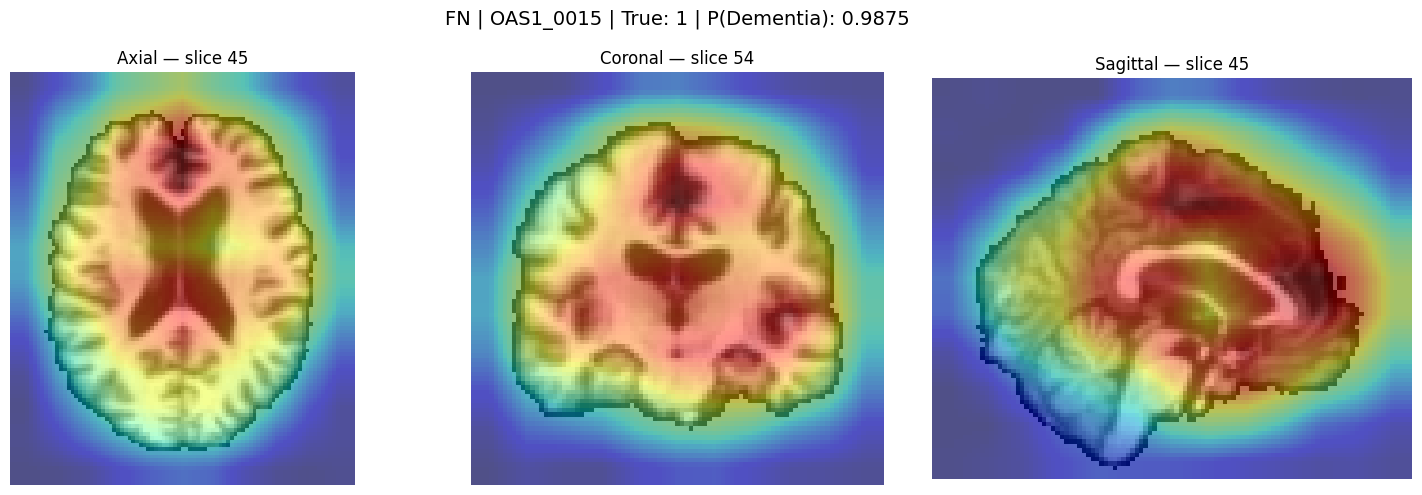

In [92]:
plot_gradcam(tn_result)
plot_gradcam(fp_result)
plot_gradcam(fn_result)